# EMG Preprocessing

**Objective:** Apply a documented preprocessing workflow to a labeled continuous sEMG trial and compare raw, band-pass filtered, rectified, and RMS-envelope signals.

**Dataset:** UCI EMG Data for Gestures  
**Sampling assumption:** 200 Hz, based on the Myo armband’s published sampling rate.  
**Scope:** Educational and research demonstration only; not for clinical use.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt

In [2]:
from google.colab import files

uploaded = files.upload()
filename = next(iter(uploaded))

df = pd.read_csv(filename, sep="\t")

df.columns = [
    "time",
    "channel_1",
    "channel_2",
    "channel_3",
    "channel_4",
    "channel_5",
    "channel_6",
    "channel_7",
    "channel_8",
    "gesture"
]

df["gesture"] = pd.to_numeric(df["gesture"])
channels = [f"channel_{i}" for i in range(1, 9)]

print("Data shape:", df.shape)
print("Gesture classes:", sorted(df["gesture"].unique()))

Saving 1_raw_data_10-38_11.04.16.txt to 1_raw_data_10-38_11.04.16.txt
Data shape: (51078, 10)
Gesture classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


In [3]:
target_gesture = 1

is_target = df["gesture"].eq(target_gesture)
block_id = is_target.ne(is_target.shift()).cumsum()

gesture_blocks = (
    df[is_target]
    .groupby(block_id[is_target])
    .agg(
        start_time=("time", "min"),
        end_time=("time", "max"),
        samples=("time", "size")
    )
    .reset_index(drop=True)
)

block_number = 0

start_time = gesture_blocks.loc[block_number, "start_time"]
end_time = gesture_blocks.loc[block_number, "end_time"]

trial = df[
    (df["gesture"] == target_gesture)
    & (df["time"] >= start_time)
    & (df["time"] <= end_time)
].copy()

print(gesture_blocks)
print(f"\nSelected trial: class {target_gesture}, {len(trial)} samples")

   start_time  end_time  samples
0         968      2661     1633
1       29871     31685     1760

Selected trial: class 1, 1633 samples


In [7]:
fs = 200
lowcut = 20
highcut = 80
filter_order = 4
rms_window_ms = 100
rms_window_samples = int(fs * rms_window_ms / 1000)

def bandpass_filter(signal, fs, lowcut, highcut, order=4):
    nyquist = fs / 2
    b, a = butter(
        order,
        [lowcut / nyquist, highcut / nyquist],
        btype="bandpass"
    )
    return filtfilt(b, a, signal)

def moving_rms(signal, window_samples):
    squared = np.square(signal)
    window = np.ones(window_samples) / window_samples
    return np.sqrt(np.convolve(squared, window, mode="same"))

print(f"Band-pass: {lowcut}-{highcut} Hz")
print(f"RMS window: {rms_window_ms} ms ({rms_window_samples} samples)")

Band-pass: 20-80 Hz
RMS window: 100 ms (20 samples)


In [8]:
selected_channel = "channel_1"
raw = trial[selected_channel].to_numpy()

filtered = bandpass_filter(
    raw,
    fs=fs,
    lowcut=lowcut,
    highcut=highcut,
    order=filter_order
)

rectified = np.abs(filtered)

envelope = moving_rms(
    filtered,
    window_samples=rms_window_samples
)

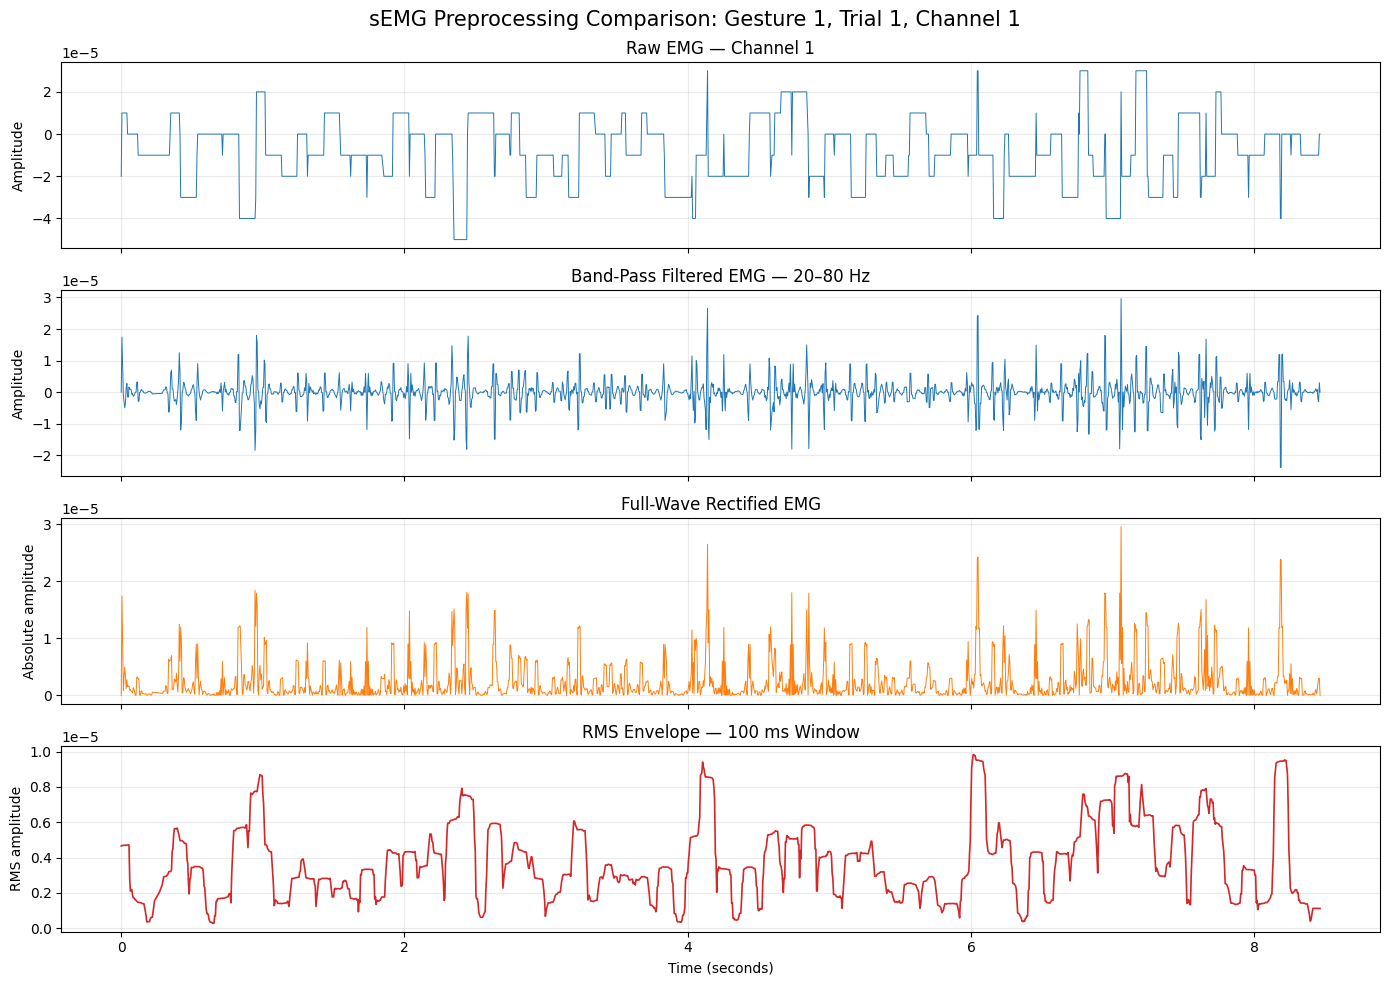

In [11]:
time_seconds = (trial["time"] - trial["time"].iloc[0]) / fs

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(time_seconds, raw, linewidth=0.7)
axes[0].set_title("Raw EMG — Channel 1")
axes[0].set_ylabel("Amplitude")
axes[0].grid(alpha=0.25)

axes[1].plot(time_seconds, filtered, linewidth=0.7, color="tab:blue")
axes[1].set_title("Band-Pass Filtered EMG — 20–80 Hz")
axes[1].set_ylabel("Amplitude")
axes[1].grid(alpha=0.25)

axes[2].plot(time_seconds, rectified, linewidth=0.7, color="tab:orange")
axes[2].set_title("Full-Wave Rectified EMG")
axes[2].set_ylabel("Absolute amplitude")
axes[2].grid(alpha=0.25)

axes[3].plot(time_seconds, envelope, linewidth=1.2, color="tab:red")
axes[3].set_title(f"RMS Envelope — {rms_window_ms} ms Window")
axes[3].set_xlabel("Time (seconds)")
axes[3].set_ylabel("RMS amplitude")
axes[3].grid(alpha=0.25)

fig.suptitle(
    "sEMG Preprocessing Comparison: Gesture 1, Trial 1, Channel 1",
    fontsize=15,
    y=0.98
)
plt.tight_layout()
plt.show()